In [1]:
import torch
from torch import nn,Tensor 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from safeguard_llm.detectors.internal.linear_probe import LinearProbe

BATCH_SIZE = 32 

In [2]:
from transformers import AutoModelForCausalLM,AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B", device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-1.7B", padding_side="left"
)
if torch.cuda.is_available():
    device = "cuda"
else: 
    device = "cpu"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


c:\Users\Ramneek\anaconda3\envs\safeguard_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:26<00:00, 11.66it/s]


In [4]:
print(model.model.layers[27])

Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
    (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
    (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
    (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((2048,), eps=1e-06)
)


In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader
toxic_dataset = load_dataset("textdetox/multilingual_toxicity_dataset")
print(toxic_dataset.data["en"])
en_dataset = toxic_dataset["en"].shuffle(seed=40)

split_dataset = en_dataset.train_test_split(test_size=0.1, seed=40)
train_toxic_dataset = split_dataset["train"]
test_toxic_dataset = split_dataset["test"]
train_data = DataLoader(train_toxic_dataset, batch_size=4)
test_data = DataLoader(test_toxic_dataset, batch_size=4)



MemoryMappedTable
text: string
toxic: int64
----
text: [["The trans women reading this tweet right now is beautiful","9) uhhhh i like being lgbt a lot. i feel proud of what i have done to help others in my community","Hero Rohit Sharma love From Pakistan","As a slightly feminine top I appreciate all masc bottoms that enjoy a dude like me","Delon Love Turkey and brave Turks from Indian Muslim! In Shaa Allah we will rise again!",...,"It's 2019 we're respecting women and getting respected back.","does skin colour matter to world leaders? does what you believe matter to world leaders?","A massive thanks from a bi teen","The least we could do this Pride month is get a trans mother back to her kids. Donate and share! U (... 2 chars omitted)","is being trans valid? please retweet after voting for"],["These women are so powerful and inspiring","God is a woman and her name is Sophie Turner","Ah. I'm planning on coming out as trans (and I guess lesbian) hopefully this week. Good luck man","You d

In [8]:
import torch
from tqdm.auto import tqdm
import numpy as np 
from sklearn import metrics
import matplotlib.pyplot as plt  

def hook(module, input: Tensor, output: Tensor) -> None:
    global activation_cache 
    activation_cache = output[:, -1, :].detach().clone().to(device)

def train_model(layer):
    linear_probe_model = LinearProbe(in_dim=2048).to(device).bfloat16()

    forward_hook = model.model.layers[layer].register_forward_hook(hook)
    optimizer = torch.optim.Adam(linear_probe_model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = torch.nn.BCEWithLogitsLoss()

    EPOCHS = 3
    linear_probe_model.train()
    for epoch in range(EPOCHS): 
        pbar = tqdm(train_data, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=True)
        
        for batch in pbar:
            inputs = batch["text"]
            labels = batch["toxic"].to(device).bfloat16()
            tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            optimizer.zero_grad() 
            loss = loss_fn(scores.squeeze(-1), labels)
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    forward_hook.remove()
    return linear_probe_model

def eval_accuracy(linear_probe_model, layer,data,threshold):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    tp_list = []
    fp_list = []
    for batch in pbar:
        inputs = batch["text"]
        labels = batch["toxic"].to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model.predict(activation_cache,threshold=threshold)
            scores = scores.squeeze(-1)
            tp += torch.sum(torch.logical_and(scores == 1 ,labels == 1))
            tn += torch.sum(torch.logical_and(scores == 0,labels == 0))
            fp += torch.sum(torch.logical_and(scores == 1,labels == 0))
            fn += torch.sum(torch.logical_and(scores == 0,labels == 1))
    tp_list.append(tp)
    fp_list.append(fp)
    print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    print(fp)
    print(tn)
    print(fn)
    accuracy = (tp + tn) /( tp + fp + tn + fn)
    print(accuracy)
    forward_hook.remove()

def roc(linear_probe_model, layer,data):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    scores_full = []
    labels_full = []
    for batch in pbar:
        inputs = batch["text"]
        labels = batch["toxic"].to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            scores_full.extend(scores.squeeze(-1).float().cpu())
            labels_full.extend(labels.float().cpu())
    fpr, tpr, thresholds = metrics.roc_curve(labels_full,scores_full)
    auroc_score = metrics.roc_auc_score(labels_full,scores_full)
    roc_auc = metrics.auc(fpr, tpr)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                    name='example estimator')
    display.plot()
    plt.show()
    print("Auroc score: ", auroc_score)
    forward_hook.remove()

In [9]:
linear_probe_model = train_model(27)
torch.save(linear_probe_model.state_dict(), "src/models/linear_probe/model_linear_toxicity_qwen3_1_7b_l27_res_stream.pt")

Epoch 1/3:  31%|███       | 44/141 [00:53<01:58,  1.22s/it, loss=1.8047]


KeyboardInterrupt: 

0.0


100%|██████████| 16/16 [00:03<00:00,  5.33it/s]


TP: 250, FP: 250, TN: 0, FN: 0
tensor(250, device='cuda:0')
tensor(0, device='cuda:0')
tensor(0, device='cuda:0')
tensor(0.5000, device='cuda:0')
0.1


100%|██████████| 16/16 [00:02<00:00,  5.79it/s]


TP: 247, FP: 29, TN: 221, FN: 3
tensor(29, device='cuda:0')
tensor(221, device='cuda:0')
tensor(3, device='cuda:0')
tensor(0.9360, device='cuda:0')
0.2


...

100%|██████████| 16/16 [00:02<00:00,  5.79it/s]


TP: 189, FP: 1, TN: 249, FN: 61
tensor(1, device='cuda:0')
tensor(249, device='cuda:0')
tensor(61, device='cuda:0')
tensor(0.8760, device='cuda:0')
0.9


100%|██████████| 16/16 [00:02<00:00,  5.76it/s]


TP: 155, FP: 1, TN: 249, FN: 95
tensor(1, device='cuda:0')
tensor(249, device='cuda:0')
tensor(95, device='cuda:0')
tensor(0.8080, device='cuda:0')


100%|██████████| 16/16 [00:02<00:00,  5.68it/s]


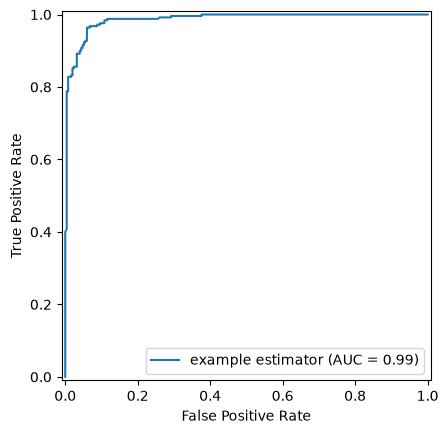

Auroc score:  0.9865359999999999


In [6]:
for t in np.linspace(0.0, 0.9, 10):
    print(t)
    eval_accuracy(linear_probe_model,27,test_data,threshold=t)

roc(linear_probe_model,27,test_data)


In [8]:
torch.save(linear_probe_model.state_dict(), "src/models/linear_probe/model_linear_toxicity_qwen3_1_7b_thres_0_3.pt")

In [4]:
linear_probe_model = LinearProbe(in_dim=3072).to(device).bfloat16()
linear_probe_model.load_state_dict(torch.load("src/models/linear_probe/model_linear.pt",weights_only=True))
linear_probe_model.eval()


LinearProbe(
  (lin): Linear(in_features=3072, out_features=1, bias=True)
  (sig): Sigmoid()
)

In [16]:
import random
from datasets import load_dataset
from torch.utils.data import DataLoader

def apply_text_perturbation(text, rate=0.08):
    """
    Applies simple character swaps, omissions, or casing changes 
    to simulate noisy, perturbed synthetic data.
    """
    if not text:
        return text
    chars = list(text)
    n_changes = max(1, int(len(chars) * rate))
    
    for _ in range(n_changes):
        idx = random.randint(0, len(chars) - 1)
        action = random.choice(["swap", "delete", "toggle_case"])
        
        if action == "swap" and idx < len(chars) - 1:
            chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]
        elif action == "delete":
            chars.pop(idx)
        elif action == "toggle_case":
            chars[idx] = chars[idx].swapcase()
            
    return "".join(chars)

# Load and shuffle dataset
toxic_dataset = load_dataset("textdetox/multilingual_toxicity_dataset")
en_dataset = toxic_dataset["en"].shuffle(seed=40)
split_dataset = en_dataset.train_test_split(test_size=0.1, seed=40)

# Create a collate function for PyTorch DataLoader to generate perturbed batches on the fly
def collate_perturbed_batches(batch):
    perturbed_texts = []
    labels = []
    
    for item in batch:
        # Assumes dataset keys are 'text' and 'toxic' (or 'label')
        original_text = item.get("text", "")
        label = item.get("toxic", item.get("label", 0))
        
        perturbed_text = apply_text_perturbation(original_text)
        perturbed_texts.append(perturbed_text)
        labels.append(label)
        
    # Convert 'labels' from a Python list to a PyTorch tensor
    return {"text": perturbed_texts, "toxic": torch.tensor(labels)}

# Initialize the DataLoader with the custom collate function
train_loader = DataLoader(
    split_dataset["train"], 
    batch_size=32, 
    collate_fn=collate_perturbed_batches
)
test_loader = DataLoader(
    split_dataset["test"], 
    batch_size=32, 
    collate_fn=collate_perturbed_batches
)

# Example output extraction matching your target nested structure
synthetic_structure = {"text": [], "toxic": []}
for i, batch in enumerate(train_loader):
    if i >= 4:  # Collect a few batches to inspect
        break
    synthetic_structure["text"].append(batch["text"])
    synthetic_structure["toxic"].append(batch["toxic"])

print("Generated Batches Layout:")
print("Texts Batch count:", len(synthetic_structure["text"]))
print("Labels Batch count:", len(synthetic_structure["toxic"]))

Generated Batches Layout:
Texts Batch count: 4
Labels Batch count: 4


100%|██████████| 16/16 [00:01<00:00,  8.05it/s]


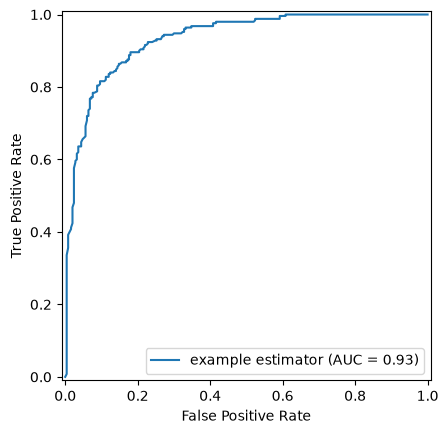

Auroc score:  0.9335519999999999


100%|██████████| 16/16 [00:01<00:00,  9.52it/s]

TP: 215, FP: 42, TN: 208, FN: 35
tensor(42, device='cuda:0')
tensor(208, device='cuda:0')
tensor(35, device='cuda:0')
tensor(0.8460, device='cuda:0')


In [19]:
roc(linear_probe_model,27,test_loader)
eval_accuracy(linear_probe_model,27,test_loader)

In [ ]:
import torch
from datasets import Dataset
from torch.utils.data import DataLoader

#ai generated synthetic dataset
synthetic_texts = [
    # 50 Highly Toxic / Hostile Sentences (Label: 1)
    "Shut the absolute fuck up, you stupid moron.",
    "You are a fucking idiot and everyone knows it.",
    "Go to hell, nobody cares about your garbage opinion.",
    "You absolute piece of shit, get off this platform.",
    "This is a fucking joke, you are incredibly stupid.",
    "Stop talking, you brainless dumbass.",
    "You're a pathetic loser who has nothing better to do.",
    "Get the fuck out of here, nobody wants you.",
    "You are a toxic asshole and a complete hypocrite.",
    "Honestly, your entire existence is a joke.",
    "You are a disgusting prick, stop lying to everyone.",
    "What a pathetic piece of trash you are.",
    "Keep crying you weak little bitch.",
    "You're too fucking stupid to understand basic logic.",
    "Nobody likes you, you worthless bastard.",
    "Go cry in a corner, you useless shit.",
    "You are a total clown, just delete your account.",
    "Shut your mouth, you annoying dumb shit.",
    "You're a fake and a complete coward.",
    "This project is pure garbage, just like your life.",
    "Stop acting like a fucking expert, you know nothing.",
    "You are a miserable, bitter asshole.",
    "I have never seen anyone so fucking incompetent.",
    "Go fuck yourself and stop bothering people.",
    "You are a brain-dead moron.",
    "Nobody gives a shit about your pathetic feelings.",
    "You are a total fraud and a disgusting cheat.",
    "Get a life, you sad little troll.",
    "Your entire argument is completely brainless and stupid.",
    "Shut the fuck up and listen for once, idiot.",
    "You are a worthless hack and a liar.",
    "I hope you lose everything, you greedy pig.",
    "You make me fucking sick to my stomach.",
    "Go back to your basement, you absolute loser.",
    "You have the IQ of a fucking rock.",
    "You are a pathetic bully and a coward.",
    "This is the dumbest piece of shit I've ever read.",
    "Nobody will ever respect a fake asshole like you.",
    "Stop whining, you irritating little crybaby.",
    "You are a toxic piece of trash.",
    "You're a stupid idiot who can't do anything right.",
    "Go ruin someone else's day, you miserable jerk.",
    "You are a disgusting, pathetic hypocrite.",
    "I honestly hate everything about you.",
    "You are an absolute clown, stop embarrassing yourself.",
    "You don't deserve any respect, you prick.",
    "This is a complete joke, you are fucking blind.",
    "Go to hell and take your stupid ideas with you.",
    "You are a useless, lazy piece of shit.",
    "Shut your face, nobody asked for your garbage input.",

    # 50 Non-toxic / Polite Sentences (Label: 0)
    "I really appreciate your perspective on this difficult topic.",
    "Thank you for sharing this detailed explanation with us.",
    "I hope you have a wonderful and productive day today!",
    "This is a very interesting point of view, let's discuss it further.",
    "Congratulations on finishing this amazing milestone!",
    "I might disagree slightly, but I understand where you are coming from.",
    "Your hard work and dedication really show in this project.",
    "Please let me know if there is anything I can do to help you.",
    "The weather today is absolutely perfect for a walk outside.",
    "I highly recommend reading this book for more insights.",
    "That is an excellent question, thank you for bringing it up.",
    "I am so glad we were able to resolve this misunderstanding.",
    "Your creativity never ceases to amaze me.",
    "Thank you for being so polite and respectful during our chat.",
    "Let's collaborate on this task when you have some free time.",
    "I hope your family is doing well and staying healthy.",
    "This is a beautiful piece of art, well done!",
    "Thank you for your constructive feedback on my work.",
    "I completely agree with the points you made in your presentation.",
    "Have a safe trip and enjoy your vacation!",
    "It is always a pleasure working with such a dedicated team.",
    "Your explanation helped me understand the problem much better.",
    "I hope you find the answers you are looking for soon.",
    "Thank you for taking the time to write such a thoughtful reply.",
    "This is a fantastic initiative, count me in!",
    "I appreciate your patience while we worked through the details.",
    "You did an outstanding job presenting the main ideas today.",
    "Let's focus on finding a positive solution together.",
    "I am looking forward to our next meeting next week.",
    "Thank you for your kindness and support during this transition.",
    "This article provides a very balanced overview of the issue.",
    "I am really proud of what we have accomplished together.",
    "Please accept my sincere congratulations on your promotion.",
    "I hope this new feature makes your workflow much easier.",
    "Thank you for raising this important point during the meeting.",
    "I find your dedication to this cause very inspiring.",
    "Let's take a quick break and resume when everyone is ready.",
    "I am happy to support you in any way that I can.",
    "Your positive attitude is contagious and much appreciated.",
    "Thank you for being such a reliable and helpful teammate.",
    "This is a very sensible approach to solving the issue.",
    "I hope you enjoy the rest of your afternoon!",
    "Your feedback has been extremely valuable to our progress.",
    "Let's keep up the great work and finish strong.",
    "Thank you for keeping us updated on the project's status.",
    "I really value your input on these technical decisions.",
    "This is a wonderful community to be a part of.",
    "I hope this summary helps clarify any outstanding questions.",
    "Thank you for your prompt response and assistance.",
    "Wishing you the very best of luck with your upcoming presentation."
]

synthetic_labels = [1] * 50 + [0] * 50

synthetic_dataset_dict = {
    "text": synthetic_texts,
    "toxic": synthetic_labels
}
synthetic_hf_dataset = Dataset.from_dict(synthetic_dataset_dict)

def collate_perturbed_batches(batch):
    perturbed_texts = []
    labels = []
    
    for item in batch:
        original_text = item.get("text", "")
        label = item.get("toxic", item.get("label", 0))
        
        perturbed_text = apply_text_perturbation(original_text)
        perturbed_texts.append(perturbed_text)
        labels.append(label)
        
    return {"text": perturbed_texts, "toxic": torch.tensor(labels)}

synthetic_loader = DataLoader(
    synthetic_hf_dataset,
    batch_size=32,
    shuffle=True,  
    collate_fn=collate_perturbed_batches
)


100%|██████████| 4/4 [00:00<00:00,  6.63it/s]


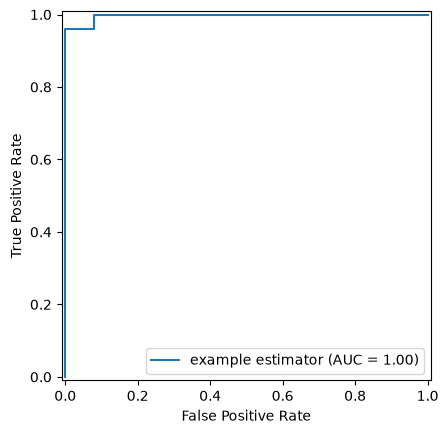

Auroc score:  0.9967999999999999


100%|██████████| 4/4 [00:00<00:00,  9.72it/s]

TP: 45, FP: 0, TN: 50, FN: 5
tensor(0, device='cuda:0')
tensor(50, device='cuda:0')
tensor(5, device='cuda:0')
tensor(0.9500, device='cuda:0')


In [33]:
roc(linear_probe_model,27,synthetic_loader)
eval_accuracy(linear_probe_model,27,synthetic_loader)